In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:

import sys
sys.path.append(
    "E:\\Quan\\AutoRoboticInspection\VIKO_UltraRobot"
)

from library import vision_robotic as vis
from ultralytics import YOLO
from config import config as CFG
import cv2

In [10]:
pwd

'e:\\Quan\\AutoRoboticInspection-v1\\VIKO_UltraRobot\\src'

In [5]:
%cd ..

e:\Quan\AutoRoboticInspection-v1\VIKO_UltraRobot


In [3]:
model  = YOLO(CFG.MODEL['YOLOV9']['WEIGHT'])

In [6]:
img =  cv2.imread('data/AI/Record_2024-05-07/20240507-104449393442-acA2440-35uc_22481496.png')

In [25]:
img.shape

(2048, 2448, 3)

In [11]:
model  = YOLO(CFG.MODEL['YOLOV9']['WEIGHT'])
img = cv2.resize(img, (640, 640), interpolation=cv2.INTER_CUBIC)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
results = model.predict(source=img, conf=0.65)
# vis.getCoordinates(model, img)


0: 640x640 1 0_degree, 39.9ms
Speed: 2.0ms preprocess, 39.9ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


In [27]:
results

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: ultralytics.engine.results.Masks object
 names: {0: '0_degree', 1: 'weld', 2: '90_degree', 3: 'other', 4: '30_degree'}
 obb: None
 orig_img: array([[[166, 188, 187],
         [158, 190, 191],
         [162, 186, 194],
         ...,
         [172, 205, 208],
         [169, 202, 215],
         [170, 198, 213]],
 
        [[160, 190, 191],
         [162, 186, 197],
         [163, 189, 189],
         ...,
         [166, 202, 211],
         [171, 203, 208],
         [171, 199, 214]],
 
        [[161, 186, 194],
         [161, 188, 193],
         [165, 186, 195],
         ...,
         [173, 197, 213],
         [168, 197, 216],
         [168, 198, 211]],
 
        ...,
 
        [[157, 186, 190],
         [158, 183, 194],
         [164, 180, 195],
         ...,
         [161, 186, 193],
         [156, 187, 196],
         [159, 187, 191]],
 
        [[159, 185

In [3]:
data = np.loadtxt('../laser/datascan-python_2024-07-16_15-36-35.txt')

In [4]:
Z_filtered = data.copy()

(640, 640, 3)


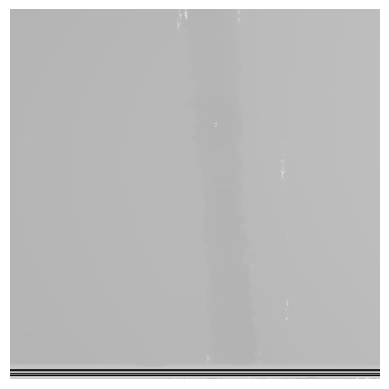

In [5]:
min_val = np.min(Z_filtered)
max_val = np.max(Z_filtered)

# Chuẩn hóa Z_filtered về khoảng [0, 1]
normalized_Z = (Z_filtered - min_val) / (max_val - min_val)

# Chuyển đổi thành màu gray scale (RGB giống nhau)
gray_image = np.stack((normalized_Z, normalized_Z, normalized_Z), axis=-1)

import cv2
gray_image = cv2.resize(gray_image, (640, 640), cv2.INTER_CUBIC)
print(gray_image.shape)
# Hiển thị mảng numpy dưới dạng heightmap
plt.imshow(gray_image)
plt.axis('off')  # Tắt trục để hiển thị màu xám
plt.show()

In [11]:
Z_filtered.shape

(2000, 2048)

In [30]:
image_rgb = (gray_image * 255).astype(np.uint8)  # Chuyển đổi về đơn vị 0-255 và kiểu dữ liệu uint8
image_rgb = cv2.cvtColor(image_rgb, cv2.COLOR_BGR2RGB) 

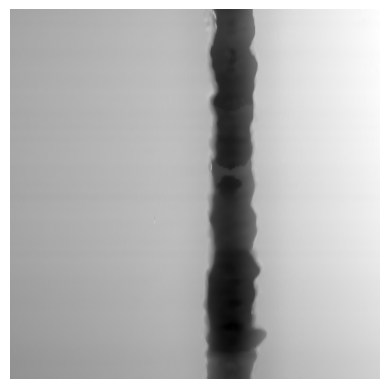

In [32]:
plt.imshow(image_rgb)
plt.axis('off')  # Tắt trục để hiển thị màu xám
plt.show()

In [ ]:
import IPCDataMs as ipc_data


data = []
filepath = 'laser/datascan.txt'
with open(filepath, 'r') as file:
    for line in file:
        row = list(map(float, line.split()))
        data.append(row)
print("3D shared memory is updated")
ipc_data.send_3Ddata(data)